# Метод стрельбы

Рассмотрим нелинейную краевую задачу:

$ \begin{equation}
\left\{
\begin{split}
y'' = F(x,y,y')| x \in [x_L,x_R] \\
l_1(y,y') = 0 | x = x_L \\ 
l_2(y,y') = 0 | x = x_R \\ 
\end{split}\right.
\end{equation} $

Основная идея решения - свести нашу задачу к задаче Коши. Для этого необходимо определить значения $y_L = y(x_L), y_L' = y'(x_L)$ или $y_R = y(x_R), y_R'  = y'(x_R) $ . Не зная $y, y'$ , из имеющейся информации сделать это аналитически может быть затруднительно, поэтому введем на левом конце дополнительное граничное условие, зависящее от параметра $\theta$:

$ \begin{equation}
\left\{
\begin{split}
y'' = F(x,y,y')| x \in [x_L,x_R] \\
l_1(y,y') = 0 | x = x_L \\ 
l_c(y,y',\theta) = 0 | x = x_L \\ 
\end{split}\right.
\end{equation} $

Выбор подходящей $l_c$ может варьироваться. В простейшем случае, $l_c(y,y',\theta) = y-\theta$ или $l_c(y,y',\theta) = y'-\theta$ , то есть $l_c = 0|x=x_L$ тождественно $y_L = \theta$ или $y_L' = \theta$ . В любом случае, задав $l_c$ и принимая во внимание $l_1$ мы должны получить простую возможность вычисления значений $y_L(\theta)$ и $y_L'(\theta)$, после чего задача сведется к задаче Коши.

Численно решив задачу Коши при конкретном $\theta$ (например, методом Рунге-Кутты), мы получим зависящий от параметра ответ $y(\theta)$, который, однако, не обязательно будет удолетворять условию на правой границе. Обозначим невязку $T(\theta) = l_2(y(\theta),y'(\theta))$ Мы будем пытаться подобрать $\theta$, при котором $T(\theta)$ становится достаточно близко к нулю. Этот процесс метафорически схож с серией пристрелочных выстрелов по цели, благодаря чему метод и получил свое название.

## Пример

Рассмотрим уравнение $y'' = \frac{(y')^2}{y} - y'\tan x $

Можно убедиться, что его решения выглядят как $ y = \alpha e^{\beta\sin x} $ . Притворимся, что мы этого не знаем, и попробуем решить краевую задачу на отрезке $[0,1]$ с $y(0) = 1$ , $y(1) = 2$

Нам нужно задать для задачи Коши $y'(0) = \theta$ 

Начнем решение

In [1]:
import numpy as np
import matplotlib.pyplot as plt

Нам удобно рассматривать эволюцию вектора состояния системы $ \vec{s} = (x,y,y') $ как:


$ \vec{s}' = D(\vec{s}) 
\Leftrightarrow  \begin{pmatrix} x \\ y \\ y' \end{pmatrix}' = \begin{pmatrix} 1 \\ y' \\ F(x,y,y') \end{pmatrix}$

In [2]:
def F(x, y, dy):
    if y <= 0:
        raise ValueError("В этом примере ищем решение с y > 0")
    return dy**2 / y - dy * np.tan(x)

In [3]:
def D(s):
    x, y, dy = s
    return np.array([1.0, dy, F(x, y, dy)])

In [4]:
X_start, X_final = 0.0, 1.0
Y_start, Y_final = 1.0, 2.0

Theta_exact = np.log(2.0) / np.sin(1.0)


def Y_exact(x):
    return np.exp(Theta_exact * np.sin(x))


def T_exact(theta):
    return np.exp(theta * np.sin(X_final)) - Y_final

Зададим численный метод (Рунге-Кутта 4 порядка) и шаг. Известно, что ошибка метода RK4 на отрезке составляет ~ O(h^4). 

In [5]:
StepsNumber = 100
DeltaX = (X_final - X_start) / StepsNumber
RootTol = 1e-10

print(f"Число шагов: {StepsNumber}; шаг h = {DeltaX:.3g}")
print(f"Допуск на численную невязку: {RootTol:.1e}")

Число шагов: 100; шаг h = 0.01
Допуск на численную невязку: 1.0e-10


Начнем со 100 шагов. Ниже проверим, какую точность это дает.

In [6]:
def RK4_step(s, h):
    d1 = h * D(s)
    d2 = h * D(s + d1 / 2)
    d3 = h * D(s + d2 / 2)
    d4 = h * D(s + d3)
    return s + (d1 + 2*d2 + 2*d3 + d4) / 6

Определим функцию невязки T, вычисляющую отклонение от нашей цели

Один выстрел выполняет функция `integrate`: она возвращает траекторию с заданным начальным наклоном. Функция `T` берет значение на правой границе и вычитает `Y_final`.

In [7]:
def integrate(theta, n_steps=StepsNumber):
    if not isinstance(n_steps, (int, np.integer)) or n_steps <= 0:
        raise ValueError("n_steps должно быть положительным целым числом")
    h = (X_final - X_start) / n_steps
    trajectory = np.empty((n_steps + 1, 3))
    trajectory[0] = [X_start, Y_start, theta]

    for step in range(n_steps):
        trajectory[step + 1] = RK4_step(trajectory[step], h)
        if not np.all(np.isfinite(trajectory[step + 1])):
            raise ValueError("Интегрирование дало нечисловое или бесконечное значение")

    return trajectory


def T(theta, n_steps=StepsNumber):
    return integrate(theta, n_steps)[-1, 1] - Y_final

Будем пытаться попасть в цель | подобрать $\theta$  методом секущих с выбором точки (regula falsi):

Дадим два наметочных выстрела (к примеру, возьмем $\theta_1,\theta_2 = 0,1$). Вычислим $d_1, d_2 = T(\theta_1), T(\theta_2)$

Для regula falsi выберем начальную пару с разными знаками невязки. Проверим это по графику.

T_h(0) = -1.000000; T_h(1) = +0.319777


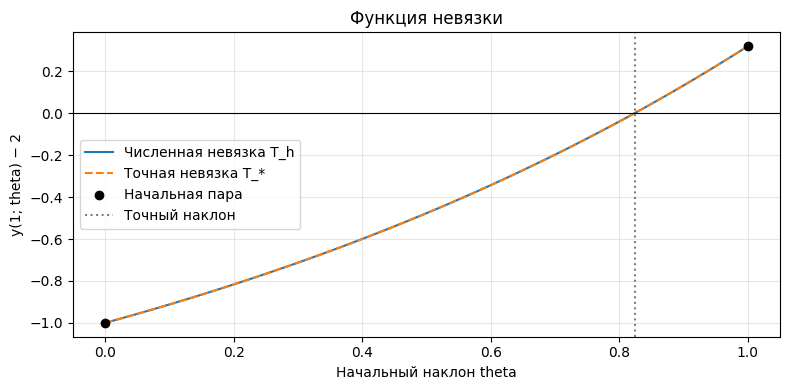

In [8]:
theta_grid = np.linspace(0.0, 1.0, 61)
residual_grid = np.array([T(theta) for theta in theta_grid])
print(f"T_h(0) = {T(0.0):+.6f}; T_h(1) = {T(1.0):+.6f}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(theta_grid, residual_grid, label="Численная невязка T_h")
ax.plot(theta_grid, T_exact(theta_grid), "--", label="Точная невязка T_*")
ax.scatter([0, 1], [T(0.0), T(1.0)], color="black", zorder=5, label="Начальная пара")
ax.axhline(0, color="black", linewidth=0.8)
ax.axvline(Theta_exact, color="gray", linestyle=":", label="Точный наклон")
ax.set(xlabel="Начальный наклон theta", ylabel="y(1; theta) − 2", title="Функция невязки")
ax.grid(alpha=0.3)
ax.legend()
fig.tight_layout()
plt.show()

Нарисуем на плоскости $ (\theta, d) $ две полученные точки и проведем прямую через них. Возьмем за $\theta_3$ $\theta$-координату точки пересечения этой прямой с абсциссой:

$$\theta_3 = \frac{d_2\theta_1-d_1\theta_2}{d_2-d_1}.$$

Построим $d_3 = T(\theta_3)$. Если точность невязки $d_3$ не устроила нас, повторим процедуру с новой парой точек: $\theta_3$ и одной из точек $(\theta_1, \theta_2)$, выбранной так:

* Если $d_1$ и $d_2$ разных знаков, выбрать $\theta$, невязка которого имеет знак, противоположный $d_3$.
* Если $d_1$ и $d_2$ одного знака, для этой реализации regula falsi нужно выбрать другую начальную пару.

При непрерывной невязке и разных знаках на концах корень остается внутри интервала. Однако один конец может долго оставаться неподвижным, поэтому быстрое сужение интервала не гарантируется. Ограничим число итераций, чтобы не получить бесконечный цикл.

In [9]:
def regula_falsi(residual, a, b, tol=RootTol, max_iter=200):
    if not a < b or tol <= 0 or max_iter <= 0:
        raise ValueError("Нужны a < b, tol > 0 и max_iter > 0")
    fa, fb = residual(a), residual(b)
    theta_history = [a, b]
    residual_history = [fa, fb]

    if not np.isfinite(fa) or not np.isfinite(fb):
        raise ValueError("Невязка на концах должна быть конечной")
    if abs(fa) <= tol:
        return a, theta_history, residual_history
    if abs(fb) <= tol:
        return b, theta_history, residual_history
    if np.sign(fa) == np.sign(fb):
        raise ValueError("Выберите границы с разными знаками невязки")

    for _ in range(max_iter):
        c = (a * fb - b * fa) / (fb - fa)
        fc = residual(c)
        if not np.isfinite(fc):
            raise ValueError("Получена неконечная невязка")
        theta_history.append(c)
        residual_history.append(fc)

        if abs(fc) <= tol:
            return c, theta_history, residual_history
        if np.sign(fc) == np.sign(fa):
            a, fa = c, fc
        else:
            b, fb = c, fc

    raise RuntimeError(f"Допуск не достигнут за {max_iter} итераций")


Theta, ThetaList, ResidualList = regula_falsi(T, 0.0, 1.0)
print("Два пробных наклона и последующие приближения:")
for i, (theta, residual) in enumerate(zip(ThetaList, ResidualList)):
    print(f"{i:2d}: theta = {theta:.12f}, T_h = {residual:+.3e}")
print(f"Шагов regula falsi: {len(ThetaList) - 2}")

Два пробных наклона и последующие приближения:
 0: theta = 0.000000000000, T_h = -1.000e+00
 1: theta = 1.000000000000, T_h = +3.198e-01
 2: theta = 0.757703864050, T_h = -1.081e-01
 3: theta = 0.818914874587, T_h = -8.092e-03
 4: theta = 0.823384022130, T_h = -5.867e-04
 5: theta = 0.823707494892, T_h = -4.245e-05
 6: theta = 0.823730892599, T_h = -3.070e-06
 7: theta = 0.823732584944, T_h = -2.221e-07
 8: theta = 0.823732707350, T_h = -1.606e-08
 9: theta = 0.823732716203, T_h = -1.162e-09
10: theta = 0.823732716844, T_h = -8.403e-11
Шагов regula falsi: 9


Метод сходится за 9 шагов при выбранных параметрах. Сравним наше полученное решение с аналитическим.
Истинное $\theta = \ln(2)/\sin(1) \approx 0.823732716961$. Посмотрим, насколько найденный параметр отличается от истинного значения. Подставив истинное значение, мы также можем проверить ошибку интегрирования:

In [10]:
Solution = integrate(Theta)
Grid = Solution[:, 0]
SolutionError = np.abs(Solution[:, 1] - Y_exact(Grid))

print(f"Найденный наклон:             {Theta:.12f}")
print(f"Точный наклон:                {Theta_exact:.12f}")
print(f"Ошибка наклона:               {abs(Theta - Theta_exact):.3e}")
print(f"Численная невязка T_h(theta):  {T(Theta):+.3e}")
print(f"Точная невязка T_*(theta):     {T_exact(Theta):+.3e}")
print(f"Невязка при точном наклоне:   {T(Theta_exact):+.3e}")
print(f"Максимальная ошибка y:        {np.max(SolutionError):.3e}")

Найденный наклон:             0.823732716844
Точный наклон:                0.823732716961
Ошибка наклона:               1.178e-10
Численная невязка T_h(theta):  -8.403e-11
Точная невязка T_*(theta):     -1.983e-10
Невязка при точном наклоне:   +1.143e-10
Максимальная ошибка y:        8.403e-11


Нет особого смысла выставлять точность выше, чем установленная точность Рунге-Кутты для задачи Коши: дальнейшее уменьшение допуска поиска корня не устранит ошибку интегрирования. Метод будет «целиться» в нуль численной невязки, немного отличающийся от точного.

Напоследок нарисуем графики сходимости. Для этого придется пересчитать всё заново, дабы вычислить траектории (мы сохранили наши решения в ThetaList)

In [11]:
# Сохраним первые пять выстрелов; окончательное решение покажем отдельно.
FirstTrajectories = [integrate(theta) for theta in ThetaList[:5]]

In [12]:
colors = plt.cm.viridis(np.linspace(0.1, 0.8, len(FirstTrajectories)))

Так как графики очень быстро сходятся, имеет смысл раскрасить в уникальные цвета только первые 5 шагов сходимости:

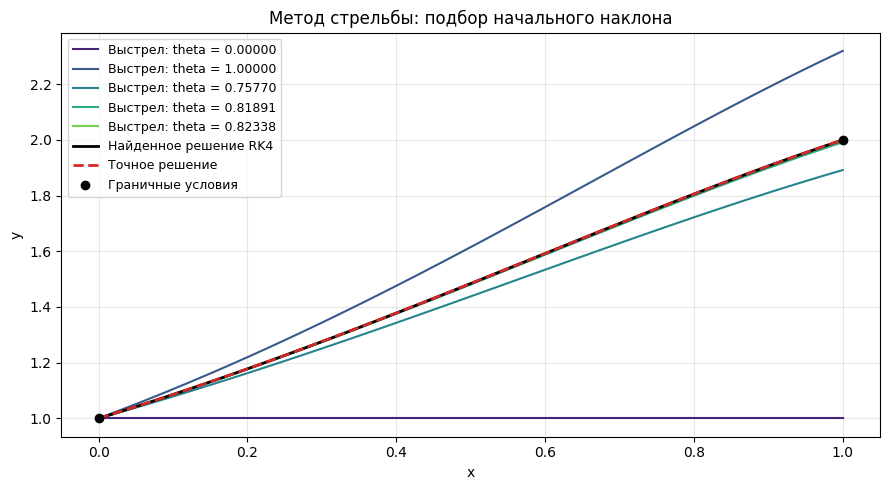

In [13]:
fig, ax = plt.subplots(figsize=(9, 5))
for theta, trajectory, color in zip(ThetaList[:5], FirstTrajectories, colors):
    ax.plot(trajectory[:, 0], trajectory[:, 1], color=color,
            label=f"Выстрел: theta = {theta:.5f}")
ax.plot(Grid, Solution[:, 1], color="black", linewidth=2, label="Найденное решение RK4")
ax.plot(Grid, Y_exact(Grid), "--", color="tab:red", linewidth=2, label="Точное решение")
ax.scatter([X_start, X_final], [Y_start, Y_final], color="black", zorder=5,
           label="Граничные условия")
ax.set(xlabel="x", ylabel="y", title="Метод стрельбы: подбор начального наклона")
ax.grid(alpha=0.3)
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

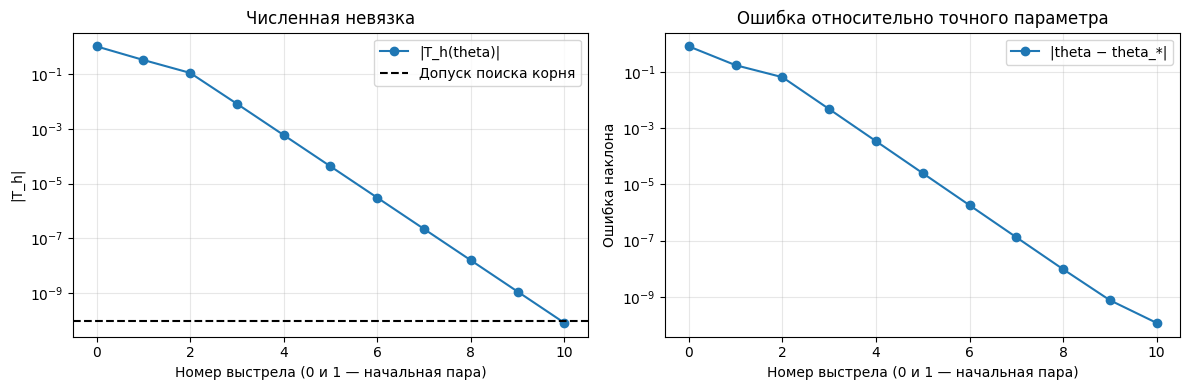

In [14]:
# Нулевые ошибки не изображаем на логарифмической оси.
def positive_or_nan(values):
    values = np.asarray(values)
    return np.where(values > 0, values, np.nan)


iterations = np.arange(len(ThetaList))
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].semilogy(iterations, positive_or_nan(np.abs(ResidualList)), "o-",
                 label="|T_h(theta)|")
axes[0].axhline(RootTol, color="black", linestyle="--", label="Допуск поиска корня")
axes[0].set(xlabel="Номер выстрела (0 и 1 — начальная пара)", ylabel="|T_h|",
            title="Численная невязка")
axes[1].semilogy(iterations, positive_or_nan(np.abs(np.array(ThetaList) - Theta_exact)),
                 "o-", label="|theta − theta_*|")
axes[1].set(xlabel="Номер выстрела (0 и 1 — начальная пара)", ylabel="Ошибка наклона",
            title="Ошибка относительно точного параметра")
for ax in axes:
    ax.grid(alpha=0.3)
    ax.legend()
fig.tight_layout()
plt.show()

## Проверка точности при уменьшении шага

Для каждого числа шагов $N$ **заново** найдём наклон и сравним решение с точным. Здесь зададим более строгий допуск поиска корня, чтобы он не скрывал ошибку RK4.

Для ошибки $E_N=\max_j|y_{h,j}-y_*(x_j)|$ оценим наблюдаемый порядок:
$$p_N=\log_2\frac{E_N}{E_{2N}}.$$
Если преобладает ошибка четвёртого порядка, удвоение $N$ уменьшает её примерно в 16 раз и $p_N\approx4$. При выходе на уровень ошибок округления или допуска поиска корня этот закон перестаёт работать.

    N          h    ошибка theta    max ошибка y        |T_h|   p для y
   10    0.10000       5.827e-07       1.396e-07    3.175e-14         —
   20    0.05000       3.970e-08       9.880e-09    3.220e-14     3.821
   40    0.02500       2.588e-09       6.568e-10    3.109e-14     3.911
   80    0.01250       1.651e-10       4.238e-11    3.131e-14     3.954
  160    0.00625       1.045e-11       2.680e-12    3.109e-14     3.983


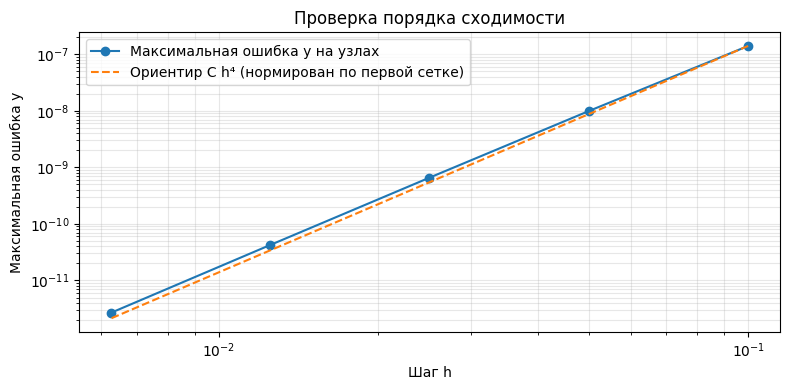

In [15]:
RefinementSteps = [10, 20, 40, 80, 160]
RefinementTol = 1e-13
Refinement = []

for n_steps in RefinementSteps:
    residual = lambda theta: T(theta, n_steps)
    theta_n, _, _ = regula_falsi(residual, 0.0, 1.0, tol=RefinementTol)
    trajectory = integrate(theta_n, n_steps)
    error_y = np.max(np.abs(trajectory[:, 1] - Y_exact(trajectory[:, 0])))
    Refinement.append((n_steps, (X_final-X_start)/n_steps,
                       abs(theta_n-Theta_exact), error_y, abs(residual(theta_n))))

Refinement = np.array(Refinement)
print(f"{'N':>5} {'h':>10} {'ошибка theta':>15} {'max ошибка y':>15} {'|T_h|':>12} {'p для y':>9}")
for i, (n_steps, h, error_theta, error_y, residual) in enumerate(Refinement):
    order = "—" if i == 0 else f"{np.log2(Refinement[i-1, 3]/error_y):.3f}"
    print(f"{int(n_steps):5d} {h:10.5f} {error_theta:15.3e} {error_y:15.3e} {residual:12.3e} {order:>9}")

fig, ax = plt.subplots(figsize=(8, 4))
h_values = Refinement[:, 1]
ax.loglog(h_values, Refinement[:, 3], "o-", label="Максимальная ошибка y на узлах")
ax.loglog(h_values, Refinement[0, 3] * (h_values/h_values[0])**4,
          "--", label="Ориентир C h⁴ (нормирован по первой сетке)")
ax.set(xlabel="Шаг h", ylabel="Максимальная ошибка y", title="Проверка порядка сходимости")
ax.grid(True, which="both", alpha=0.3)
ax.legend()
fig.tight_layout()
plt.show()

## Итоги и вопросы для самостоятельной проверки

- Стрельба превратила краевую задачу в уравнение относительно начального наклона. Каждый вызов невязки требует решения задачи Коши.
- Regula falsi сохраняет интервал с корнем при разных знаках непрерывной невязки на концах.
- Малая численная невязка контролирует выполнение правого условия для численной траектории. Точность самого решения проверяется отдельно.
- Изменение шага и сравнение с точным решением позволяют проверить порядок метода, а не предполагать точность по названию RK4.

**Попробуйте:**

1. Возьмите начальный интервал $[0,0.5]$. Объясните отказ поиска и подберите подходящий интервал по графику невязки.
2. На грубой сетке $N=10$ сравните допуски поиска корня $10^{-6}$, $10^{-10}$ и $10^{-13}$. Улучшается ли ошибка решения так же сильно, как невязка?
3. Сравните число вызовов невязки у regula falsi и бисекции при одинаковом допуске и одном интервале.

**Переход к методу Ньютона.** Можно оставить интегратор и невязку теми же, заменив только способ обновления наклона:
$$\theta_{n+1}=\theta_n-\frac{T_h(\theta_n)}{T_h'(\theta_n)}.$$
Производную численной невязки можно оценивать разностями. Вопрос следующего примера: как выбрать шаг дифференцирования и начальное приближение?